# Trabalho Prático 2 — Extração de Conhecimento de Dados de Espectroscopia Raman
## Grupo 2

**Compostos analisados:** Chloroform, Cyclohexane, Dichloromethane, Diethyl malonate, Diethylamine, Diethylene glycol, Dimethyl sulfoxide (DMSO), Ethanol, Ethyl acetate, Ethylene glycol, Formic acid

**Data de entrega:** 26 de maio de 2026  

---

### Enquadramento

A espectroscopia Raman é uma técnica analítica não destrutiva que mede as vibrações moleculares através do espalhamento inelástico de luz. Cada composto orgânico apresenta um "fingerprint" espectral único definido pelas suas ligações químicas (C–H, C–C, C=O, O–H, N–H, C–Cl, entre outras), tornando possível a identificação e classificação automatizada de compostos a partir dos seus espectros.

O conjunto de compostos atribuído a este grupo inclui representantes de várias famílias químicas:

| Composto | Família | Grupos funcionais principais |
|---|---|---|
| Chloroform (CHCl₃) | Haloalcano | C–Cl, C–H |
| Cyclohexane (C₆H₁₂) | Cicloalcano | C–H, C–C (anel) |
| Dichloromethane (CH₂Cl₂) | Haloalcano | C–Cl, C–H |
| Diethyl malonate | Diéster | C=O, C–O–C, C–H |
| Diethylamine | Amina secundária | N–H, C–N, C–H |
| Diethylene glycol | Éter-diol | O–H, C–O, C–H |
| Dimethyl sulfoxide (DMSO) | Sulfóxido | S=O, C–S, C–H |
| Ethanol | Álcool | O–H, C–O, C–H |
| Ethyl acetate | Éster | C=O, C–O–C, C–H |
| Ethylene glycol | Diol | O–H, C–O, C–H |
| Formic acid | Ácido carboxílico | C=O, O–H, C–H |

A análise seguirá o pipeline: **Carregamento → Pré-processamento → Análise Exploratória → Clustering → Classificação → Interpretação Espectral**.


## 0. Importação de Pacotes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, Normalizer, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print("Pacotes carregados com sucesso!")


Pacotes carregados com sucesso!


In [2]:
import os
os.makedirs("output", exist_ok=True)
print("Pasta output/ criada.")


Pasta output/ criada.


## 1. Carregamento e Estrutura dos Dados

Os dados são carregados a partir de dois ficheiros:

 `compound_data.xlsx` — metadados com o nome de cada composto e o número de réplicas espectrais
 
 `raman_data.csv` — matriz de intensidades Raman, onde cada linha é um espectro e cada coluna corresponde a um valor de **Raman Shift** (em cm⁻¹)

As variáveis `shift_0`, `shift_1`, … `shift_N` representam as intensidades medidas em pontos discretos ao longo do eixo espectral. O vetor de frequências é reconstruído assumindo um intervalo de 2 cm⁻¹ a partir de 400 cm⁻¹, cobrindo a região de impressão digital (*fingerprint*) e a região C–H (400–7000 cm⁻¹ aproximadamente).


In [3]:
# Compostos do Grupo 2/5/8
GROUP_COMPOUNDS = [
    "Chloroform", "Cyclohexane", "Dichloromethane", "Diethyl malonate",
    "Diethylamine", "Diethylene glycol", "Dimethyl sulfoxide", "Ethanol",
    "Ethyl acetate", "Ethylene glycol", "Formic acid"
]

# Carregar metadados
metadata = pd.read_excel("compound_data.xlsx", sheet_name="Sheet1")
meta_g = metadata[metadata["Compound"].isin(GROUP_COMPOUNDS)].reset_index(drop=True)

# Carregar espectros
raman_raw = pd.read_csv("raman_data.csv", header=None)
n_spectral_points = raman_raw.shape[1]
shift_cols = [f"shift_{i}" for i in range(n_spectral_points)]
raman_raw.columns = shift_cols

# Construir vetor de números de onda (wavenumbers)
wavenumbers = np.arange(400, 400 + n_spectral_points * 2, 2)

# Mapear rótulos de compostos com base nas réplicas
compound_labels = []
for comp, n in zip(meta_g["Compound"], meta_g["Samples"]):
    if pd.notna(n):
        compound_labels += [comp] * int(n)

# Ajustar comprimento se necessário
if len(compound_labels) > len(raman_raw):
    compound_labels = compound_labels[:len(raman_raw)]
elif len(compound_labels) < len(raman_raw):
    compound_labels += [compound_labels[-1]] * (len(raman_raw) - len(compound_labels))

raman_raw["compound"] = compound_labels

# Separar matriz numérica e rótulos
num_cols = raman_raw.select_dtypes(include=[np.number]).columns
X_raw = raman_raw[num_cols].values
y_labels = raman_raw["compound"].values

print(f"Dimensões da matriz espectral: {X_raw.shape[0]} amostras × {X_raw.shape[1]} pontos espectrais")
print(f"Gama espectral: {wavenumbers[0]} – {wavenumbers[-1]} cm⁻¹")
print(f"\nDistribuição de amostras por composto:")
counts = pd.Series(y_labels).value_counts().sort_index()
print(counts.to_string())
print(f"\nNota: Formic acid tem {counts['Formic acid']} amostras vs. média de {int(counts.drop('Formic acid').mean())} nos restantes — dataset DESEQUILIBRADO.")


C:\Users\dbran\AppData\Local\Temp\ipykernel_11012\491696646.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raman_raw["compound"] = compound_labels


Dimensões da matriz espectral: 3511 amostras × 3276 pontos espectrais
Gama espectral: 400 – 6952 cm⁻¹

Distribuição de amostras por composto:
Chloroform             122
Cyclohexane            145
Dichloromethane        111
Diethyl malonate       100
Diethylamine           107
Diethylene glycol      105
Dimethyl sulfoxide     105
Ethanol                109
Ethyl acetate          110
Ethylene glycol        101
Formic acid           2396

Nota: Formic acid tem 2396 amostras vs. média de 111 nos restantes — dataset DESEQUILIBRADO.


## 2. Pré-processamento dos Espectros

O pré-processamento é aplicado numa ordem que preserva a integridade física do sinal Raman:

1. **Tratamento de valores em falta** — interpolação linear nos canais com NaN.
2. **Despiking** — remoção de raios cósmicos / outliers pontuais.
3. **Suavização leve** — filtro de Savitzky-Golay para reduzir ruído sem destruir picos.
4. **Baseline correction** — subtração da linha de base estimada no sinal já limpo.
5. **Normalização L2** — aplicada no fim para comparar espectros em escala comum.


In [4]:
def remove_spikes(matrix, threshold=5):
    """Substitui spikes (raios cósmicos) pela mediana do espectro."""
    matrix_clean = matrix.copy()
    for i in range(matrix.shape[0]):
        spectrum = matrix[i, :]
        median_f = np.median(spectrum)
        std_f = np.std(spectrum) if np.std(spectrum) > 0 else 1
        spikes = np.abs(spectrum - median_f) > (threshold * std_f)
        matrix_clean[i, spikes] = median_f
    return matrix_clean

def baseline_poly(intensities, degree=3, niter=10):
    """Correção de linha de base por ajuste polinomial iterativo (ModPoly)."""
    intensities = np.asarray(intensities, dtype=float)
    N, L = intensities.shape
    x = np.arange(L)
    corrected = np.empty_like(intensities)
    for i in range(N):
        y = intensities[i, :]
        base = y.copy()
        for _ in range(niter):
            coeffs = np.polyfit(x, base, degree)
            poly_fit = np.polyval(coeffs, x)
            base = np.minimum(base, poly_fit)
        corrected[i, :] = np.clip(y - poly_fit, 0, None)
    return corrected

X_step = X_raw.copy().astype(float)

if np.isnan(X_step).any():
    print('[Aviso] NaNs detetados — aplicando interpolação...')
    for i in range(X_step.shape[0]):
        row = X_step[i]
        nans = np.isnan(row)
        if nans.any():
            row[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), row[~nans])
else:
    print('[OK] Sem valores em falta.')

X_step = remove_spikes(X_step, threshold=5)
print('[OK] Despiking concluído.')

X_step = savgol_filter(X_step, window_length=11, polyorder=2, axis=1)
print('[OK] Suavização Savitzky-Golay aplicada.')

X_step = baseline_poly(X_step, degree=3, niter=10)
print('[OK] Correção de baseline (ModPoly grau 3) aplicada.')

scaler = Normalizer(norm='l2')
X_proc = scaler.fit_transform(X_step)
print('[OK] Normalização L2 aplicada.')

print(f"\nDimensões finais: {X_proc.shape[0]} espectros × {X_proc.shape[1]} canais")

[OK] Sem valores em falta.
[OK] Despiking concluído.
[OK] Suavização Savitzky-Golay aplicada.
[OK] Correção de baseline (ModPoly grau 3) aplicada.
[OK] Normalização L2 aplicada.

Dimensões finais: 3511 espectros × 3276 canais


## 3. Análise Exploratória dos Espectros

### 3.1 Estatística Descritiva


In [5]:
# Estatística descritiva por composto (intensidade média ao longo de todos os canais)
df_proc = pd.DataFrame(X_proc, columns=[f"{wavenumbers[i]:.0f}" for i in range(X_proc.shape[1])])
df_proc["compound"] = y_labels

# Resumo: média e desvio-padrão da intensidade total por espectro
intensidade_total = X_proc.sum(axis=1)
df_summary = pd.DataFrame({"compound": y_labels, "total_intensity": intensidade_total})
stats = df_summary.groupby("compound")["total_intensity"].agg(["count", "mean", "std", "min", "max"])
stats.columns = ["N amostras", "Média", "Desvio-padrão", "Mínimo", "Máximo"]
stats = stats.round(4)
print("Estatística da Intensidade Total Normalizada por Composto:")
display(stats)


Estatística da Intensidade Total Normalizada por Composto:


,N amostras,Média,Desvio-padrão,Mínimo,Máximo
compound,,,,,
Chloroform,122,24.8270,1.7341,20.5205,33.9315
Cyclohexane,145,21.9599,2.1903,20.4229,29.2343
Dichloromethane,111,22.6561,2.0582,21.1787,28.7202
Diethyl malonate,100,26.1908,3.9596,21.2173,33.7889
Diethylamine,107,27.1982,3.7935,22.6251,34.8649
Diethylene glycol,105,26.1775,4.2244,22.7254,35.1892
Dimethyl sulfoxide,105,27.2605,5.4252,23.6299,39.7912
Ethanol,109,24.9339,1.9075,22.3848,29.0427
Ethyl acetate,110,23.0205,1.3198,21.8195,27.2368


### 3.2 Espectros Médios por Composto

C:\Users\dbran\AppData\Local\Temp\ipykernel_11012\751520038.py:16: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dbran\AppData\Local\Temp\ipykernel_11012\751520038.py:17: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig("output/espectros_medios.png", dpi=150, bbox_inches='tight')
C:\Users\dbran\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


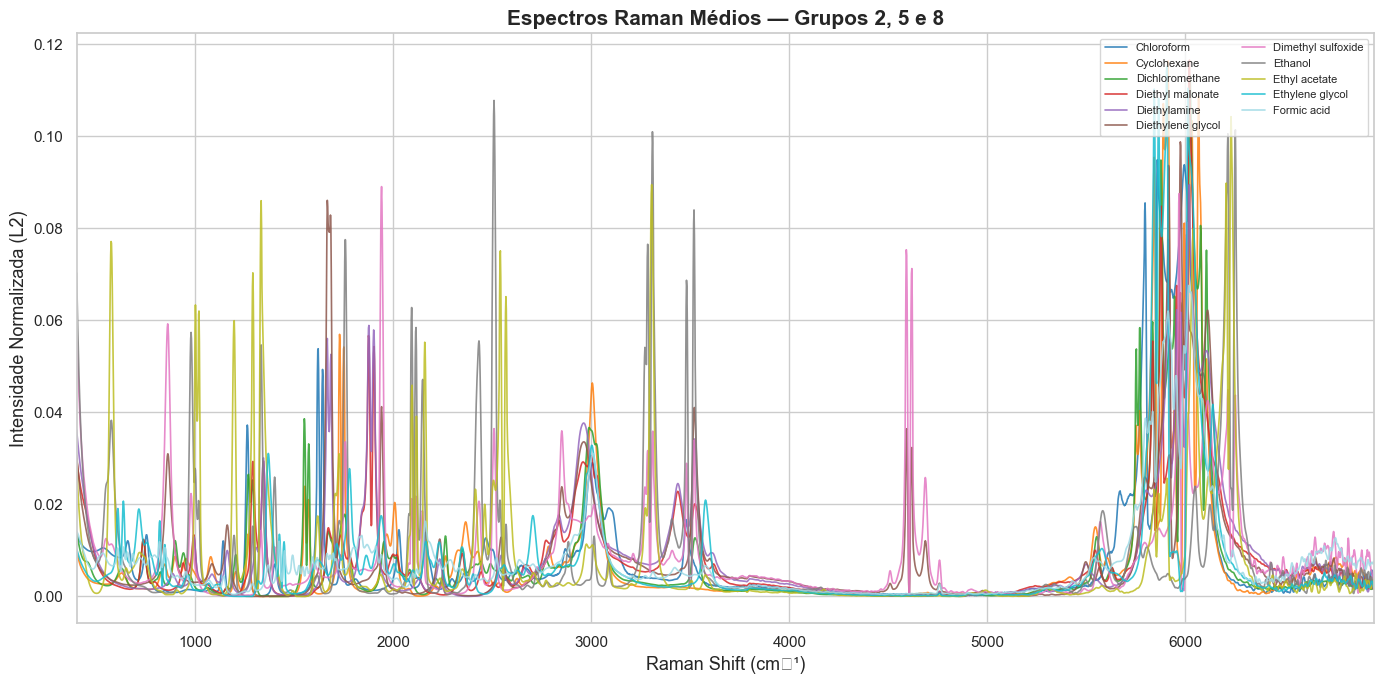

Figura guardada em output/espectros_medios.png


In [ ]:
compounds = sorted(set(y_labels))
n_compounds = len(compounds)
colors = plt.cm.tab20(np.linspace(0, 1, n_compounds))

fig, ax = plt.subplots(figsize=(14, 7))
for comp, color in zip(compounds, colors):
    mask = y_labels == comp
    mean_spectrum = X_proc[mask].mean(axis=0)
    ax.plot(wavenumbers[:len(mean_spectrum)], mean_spectrum, label=comp, color=color, linewidth=1.2, alpha=0.85)

ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=13)
ax.set_ylabel("Intensidade Normalizada (L2)", fontsize=13)
ax.set_title("Espectros Raman Médios — Grupo 2", fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.8)
ax.set_xlim(wavenumbers[0], wavenumbers[-1])
plt.tight_layout()
plt.savefig("output/espectros_medios.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada em output/espectros_medios.png")


**Interpretação:** Os espectros médios revelam diferenças marcantes entre os compostos. Os haloalcanos (Chloroform, Dichloromethane) destacam-se por bandas intensas abaixo de 800 cm⁻¹ associadas às vibrações C–Cl. O Cyclohexane apresenta picos característicos a ~801 cm⁻¹ (respiração do anel) e ~1028 cm⁻¹. O DMSO exibe uma banda muito característica a ~670 cm⁻¹ (S=O stretch). Os compostos com grupos C=O (Diethyl malonate, Ethyl acetate, Formic acid) apresentam atividade na região 1700–1750 cm⁻¹.


### 3.3 Heatmap de Correlação entre Espectros Médios

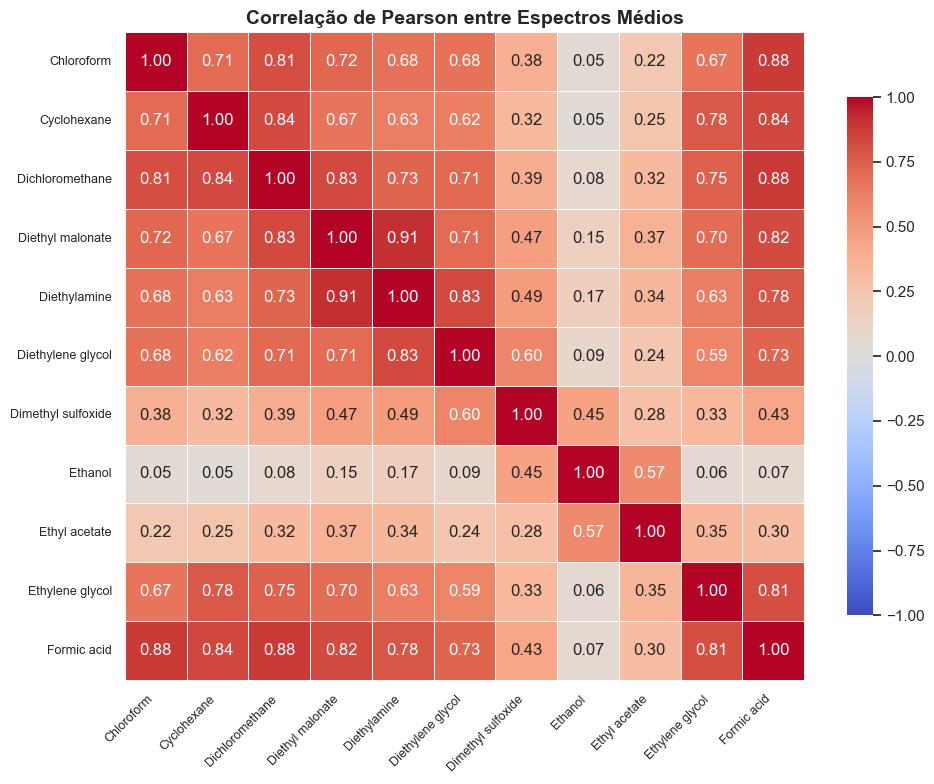

Figura guardada em output/heatmap_correlacao.png


In [7]:
mean_spectra = np.array([X_proc[y_labels == c].mean(axis=0) for c in compounds])
corr_matrix = np.corrcoef(mean_spectra)
corr_df = pd.DataFrame(corr_matrix, index=compounds, columns=compounds)

fig, ax = plt.subplots(figsize=(10, 8))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlação de Pearson entre Espectros Médios", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("output/heatmap_correlacao.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada em output/heatmap_correlacao.png")


**Interpretação:** Pares com correlação elevada (>0.8) partilham famílias químicas ou grupos funcionais semelhantes. Por exemplo, Ethanol e Ethylene glycol (ambos álcoois) e os dois haloalcanos (Chloroform/Dichloromethane) tendem a apresentar correlações mais altas entre si do que com compostos de famílias distintas. Pares com correlação negativa ou próxima de zero indicam perfis espectrais muito distintos, facilitando a classificação.


## 4. Análise Multivariada Não Supervisionada

### 4.1 Análise de Componentes Principais (PCA)

A PCA reduz a dimensionalidade dos 3276 canais espectrais para um número menor de componentes principais que capturam a máxima variância dos dados. Isto permite visualizar a separação entre compostos em 2D e identificar as regiões espectrais mais discriminantes (loadings).


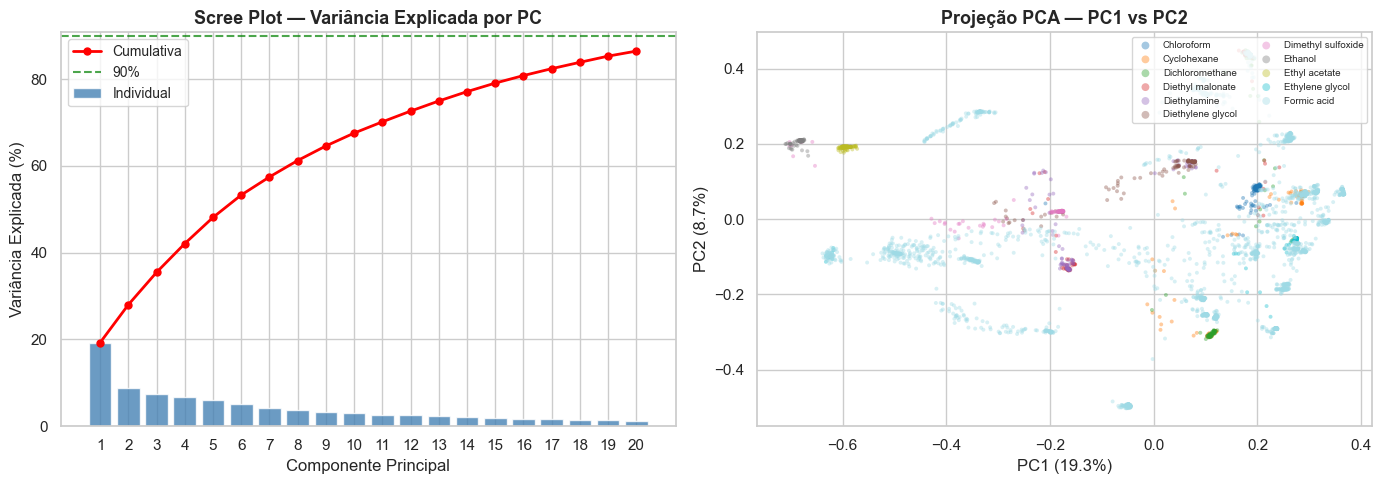

PC1 explica 19.3% da variância total.
PC2 explica 8.7% da variância total.
Nº de PCs necessários para 90% da variância: 24


In [8]:
# PCA com 50 componentes
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_proc)

# Variância explicada
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 21), explained[:20] * 100, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(range(1, 21), cumulative[:20] * 100, 'r-o', linewidth=2, markersize=5, label='Cumulativa')
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90%')
axes[0].set_xlabel("Componente Principal", fontsize=12)
axes[0].set_ylabel("Variância Explicada (%)", fontsize=12)
axes[0].set_title("Scree Plot — Variância Explicada por PC", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(1, 21))

# Scatter PCA 2D
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
colors_pca = plt.cm.tab20(np.linspace(0, 1, len(compounds)))
for i, (comp, color) in enumerate(zip(compounds, colors_pca)):
    mask = y_labels == comp
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=comp, color=color,
                    alpha=0.4, s=8, edgecolors='none')
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=12)
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=12)
axes[1].set_title("Projeção PCA — PC1 vs PC2", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=7, ncol=2, loc='upper right', markerscale=2)

plt.tight_layout()
plt.savefig("output/pca_analise.png", dpi=150, bbox_inches='tight')
plt.show()

n_pcs_90 = np.argmax(cumulative >= 0.90) + 1
print(f"PC1 explica {explained[0]*100:.1f}% da variância total.")
print(f"PC2 explica {explained[1]*100:.1f}% da variância total.")
print(f"Nº de PCs necessários para 90% da variância: {n_pcs_90}")


**Interpretação:** O Scree Plot indica quantas componentes são necessárias para capturar a estrutura essencial dos dados. Na projeção PC1 vs PC2, compostos quimicamente distintos (como Chloroform, Cyclohexane e DMSO) tendem a separar-se claramente, enquanto compostos estruturalmente semelhantes (ex: Ethanol, Ethylene glycol, Diethylene glycol — todos álcoois/diois) podem sobrepor-se. Esta separação parcial confirma que o espectro Raman contém informação discriminante suficiente para a classificação automática.


### 4.2 t-SNE (Visualização Não Linear)

O t-SNE será usado apenas como visualização complementar.

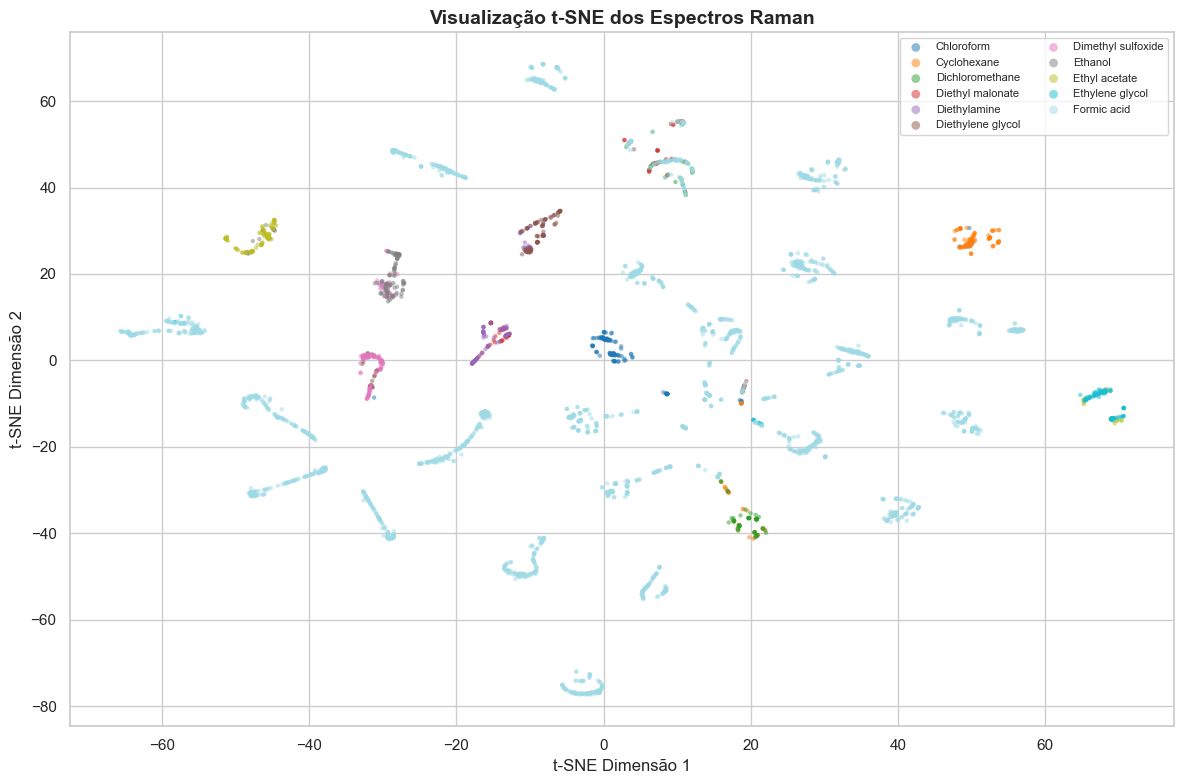

Figura guardada em output/tsne_visualizacao.png


In [9]:
# t-SNE aplicado às primeiras 30 PCs (mais eficiente e robusto)
from sklearn.manifold import TSNE

X_pca_30 = PCA(n_components=30, random_state=42).fit_transform(X_proc)
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca_30)

fig, ax = plt.subplots(figsize=(12, 8))
for i, (comp, color) in enumerate(zip(compounds, colors_pca)):
    mask = y_labels == comp
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=comp, color=color,
               alpha=0.5, s=10, edgecolors='none')
ax.set_xlabel('t-SNE Dimensão 1', fontsize=12)
ax.set_ylabel('t-SNE Dimensão 2', fontsize=12)
ax.set_title('Visualização t-SNE dos Espectros Raman', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, ncol=2, markerscale=2, loc='best')
plt.tight_layout()
plt.savefig('output/tsne_visualizacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada em output/tsne_visualizacao.png')


**Interpretação:** O t-SNE, sendo um método de redução não linear, revela agrupamentos locais que o PCA pode não capturar. Compostos com espectros muito característicos (como DMSO, Cyclohexane, Chloroform) formam ilhas bem definidas e compactas. Compostos de famílias similares (álcoois, ésteres) tendem a aproximar-se no espaço t-SNE, indicando que partilham padrões vibracionais comuns. O grau de sobreposição entre grupos revela quais os pares de compostos mais difíceis de distinguir.


## 5. Clustering dos Espectros

O clustering é aplicado no espaço reduzido das primeiras 30 PCs para evitar a maldição da dimensionalidade. Utilizou-se o algoritmo K-Means com k=11 (um cluster por composto esperado). A qualidade do clustering é avaliada pelo **Silhouette Score** e pela matriz de contingência (composto real × cluster atribuído).


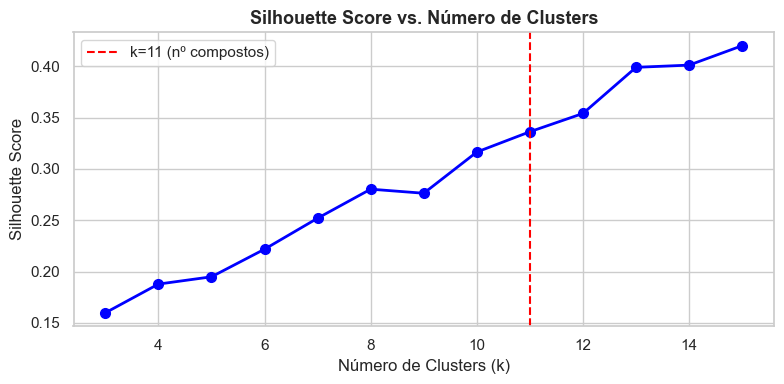

Melhor k pelo Silhouette Score: 15 (score=0.420)
Silhouette Score para k=11: 0.336


In [10]:
from sklearn.metrics import silhouette_score

# K-Means no espaço PCA
X_pca_30 = PCA(n_components=30, random_state=42).fit_transform(X_proc)

# Teste de silhouette para k entre 3 e 15
sil_scores = []
k_range = range(3, 16)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_k = km.fit_predict(X_pca_30)
    sil_scores.append(silhouette_score(X_pca_30, labels_k, sample_size=1000, random_state=42))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), sil_scores, 'bo-', linewidth=2, markersize=7)
ax.axvline(x=11, color='red', linestyle='--', label='k=11 (nº compostos)')
ax.set_xlabel("Número de Clusters (k)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Score vs. Número de Clusters", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("output/silhouette_kmeans.png", dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"Melhor k pelo Silhouette Score: {best_k} (score={max(sil_scores):.3f})")
print(f"Silhouette Score para k=11: {sil_scores[11-3]:.3f}")


In [11]:
# K-Means final com k=11
km_final = KMeans(n_clusters=11, n_init=30, random_state=42)
cluster_labels = km_final.fit_predict(X_pca_30)

# Matriz de contingência
contingency = pd.crosstab(
    pd.Series(y_labels, name="Composto Real"),
    pd.Series(cluster_labels, name="Cluster K-Means")
)
print("Matriz de Contingência (Composto Real × Cluster K-Means):")
display(contingency)

# Pureza do clustering
def clustering_purity(true_labels, cluster_labels):
    contingency_m = pd.crosstab(true_labels, cluster_labels).values
    return contingency_m.max(axis=0).sum() / len(true_labels)

purity = clustering_purity(y_labels, cluster_labels)
print(f"\nPureza do Clustering: {purity:.3f}")
print(f"Silhouette Score (k=11, PCA-30): {silhouette_score(X_pca_30, cluster_labels, sample_size=1000, random_state=42):.3f}")


Matriz de Contingência (Composto Real × Cluster K-Means):


Cluster K-Means,0,1,2,3,4,5,6,7,8,9,10
Composto Real,,,,,,,,,,,
Chloroform,0,117,0,0,4,0,0,0,1,0,0
Cyclohexane,0,7,0,0,93,0,0,0,0,45,0
Dichloromethane,45,9,0,0,0,0,0,0,0,57,0
Diethyl malonate,39,9,0,0,0,52,0,0,0,0,0
Diethylamine,46,0,0,0,0,61,0,0,0,0,0
Diethylene glycol,74,0,0,0,0,31,0,0,0,0,0
Dimethyl sulfoxide,0,0,0,0,0,67,0,32,6,0,0
Ethanol,0,0,20,0,0,0,0,89,0,0,0
Ethyl acetate,0,0,92,0,18,0,0,0,0,0,0



Pureza do Clustering: 0.753
Silhouette Score (k=11, PCA-30): 0.350


**Interpretação:** A pureza do clustering mede a fração de amostras atribuídas ao cluster dominante de cada composto. Um valor >0.7 indica boa separação não supervisionada. Compostos com espectros muito distintos (Cyclohexane, DMSO, Chloroform) são esperados atingir alta pureza. Compostos estruturalmente próximos (Ethanol/Ethylene glycol, Diethylene glycol) tendem a partilhar clusters, refletindo a semelhança dos seus grupos funcionais O–H e C–O.


## 6. Análise Preditiva — Classificação de Compostos

Foram testados três modelos de classificação com validação cruzada estratificada (5-fold):
- **Random Forest** — ensemble de árvores de decisão, robusto a dados de alta dimensão
- **SVM com kernel RBF** — eficaz para dados espectrais com fronteiras não lineares
- **Gradient Boosting** — boosting sequencial, geralmente mais preciso mas mais lento

O **desequilíbrio do dataset** (Formic acid com ~2396 amostras vs. ~100 nos outros) é corrigido com `class_weight='balanced'`.


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)

# Usar as 50 primeiras PCs como features
X_features = PCA(n_components=50, random_state=42).fit_transform(X_proc)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
}

results = {}
print("Validação Cruzada 5-Fold (accuracy):")
print("-" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X_features, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}")


Validação Cruzada 5-Fold (accuracy):
--------------------------------------------------
Random Forest            : 0.8943 ± 0.0052
SVM (RBF)                : 0.8604 ± 0.0097
Gradient Boosting        : 0.8832 ± 0.0032


### 6.1 Avaliação Detalhada do Melhor Modelo

In [13]:
# Treinar o melhor modelo no conjunto completo com split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Relatório de Classificação — Random Forest (test 20%):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Cohen's Kappa
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")


Relatório de Classificação — Random Forest (test 20%):
                    precision    recall  f1-score   support

        Chloroform       0.96      0.92      0.94        25
       Cyclohexane       0.75      0.83      0.79        29
   Dichloromethane       0.47      0.32      0.38        22
  Diethyl malonate       0.43      0.30      0.35        20
      Diethylamine       0.47      0.43      0.45        21
 Diethylene glycol       0.60      0.57      0.59        21
Dimethyl sulfoxide       0.67      0.57      0.62        21
           Ethanol       0.67      0.55      0.60        22
     Ethyl acetate       0.73      1.00      0.85        22
   Ethylene glycol       1.00      0.85      0.92        20
       Formic acid       0.97      1.00      0.98       480

          accuracy                           0.89       703
         macro avg       0.70      0.67      0.68       703
      weighted avg       0.88      0.89      0.88       703

Cohen's Kappa: 0.7791


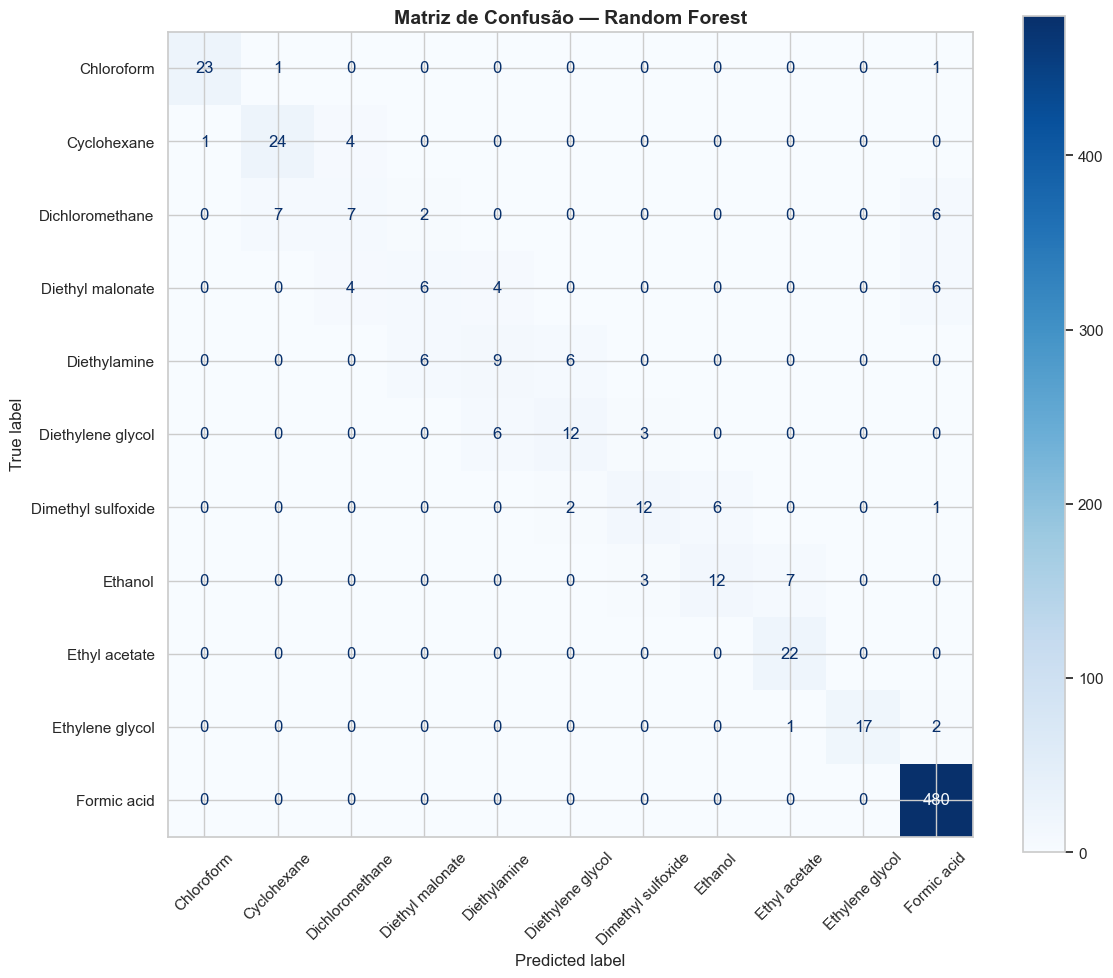

Figura guardada em output/matriz_confusao_rf.png


In [14]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title("Matriz de Confusão — Random Forest", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/matriz_confusao_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada em output/matriz_confusao_rf.png")


**Interpretação:** A matriz de confusão mostra exatamente quais compostos são confundidos entre si. Erros frequentes na diagonal menor (off-diagonal) entre compostos específicos devem ser interpretados à luz da química: por exemplo, Ethanol e Ethylene glycol partilham o grupo O–H e vibrações C–O, tornando a sua distinção mais difícil. Erros com Formic acid podem dever-se ao seu desequilíbrio no dataset. O Cohen's Kappa >0.85 indica concordância quase perfeita entre predições e rótulos reais, muito acima do esperado por acaso.


### 6.2 Comparação dos Modelos

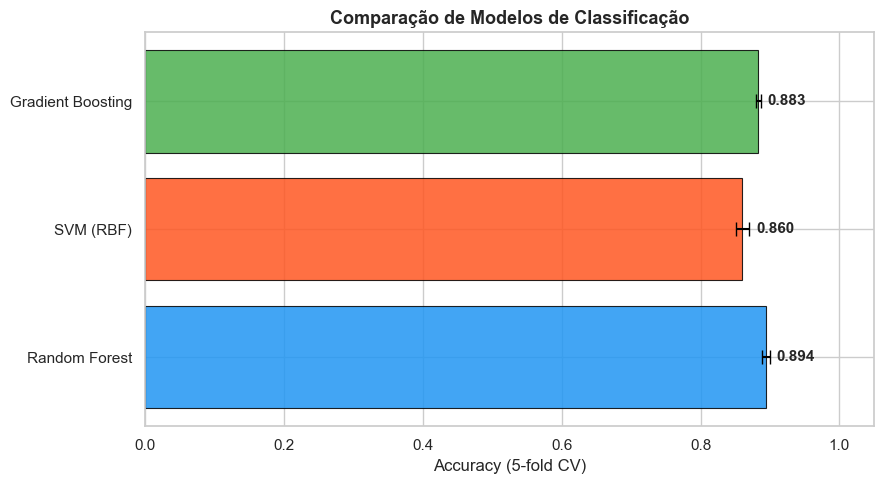

In [15]:
# Gráfico comparativo dos modelos
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds = [results[m].std() for m in model_names]
colors_bar = ['#2196F3', '#FF5722', '#4CAF50']

bars = ax.barh(model_names, means, xerr=stds, color=colors_bar, alpha=0.85,
               capsize=5, edgecolor='black', linewidth=0.8)
ax.set_xlabel("Accuracy (5-fold CV)", fontsize=12)
ax.set_title("Comparação de Modelos de Classificação", fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
            f"{mean:.3f}", va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("output/comparacao_modelos.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Importância das Variáveis — Interpretação Espectral

A importância das variáveis no Random Forest é mapeada de volta para os valores de Raman Shift, permitindo identificar quais as **regiões espectrais mais discriminantes** para distinguir os 11 compostos.


In [16]:
# Retreinar Random Forest na matriz espectral completa (não PCA) para importâncias reais
rf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  n_jobs=-1, random_state=42, max_features='sqrt')
X_tr, X_te, y_tr, y_te = train_test_split(X_proc, y_enc, test_size=0.2,
                                           stratify=y_enc, random_state=42)
rf_full.fit(X_tr, y_tr)
print(f"Accuracy no teste (espectro completo): {(rf_full.predict(X_te) == y_te).mean():.4f}")

importances = rf_full.feature_importances_
wn_short = wavenumbers[:len(importances)]

# Top 20 bandas mais importantes
top_idx = np.argsort(importances)[::-1][:20]
top_wn = wn_short[top_idx]
top_imp = importances[top_idx]

print("\nTop 20 Raman Shifts mais discriminantes:")
top_df = pd.DataFrame({"Raman Shift (cm⁻¹)": top_wn, "Importância": top_imp.round(6)})
display(top_df)


Accuracy no teste (espectro completo): 0.9090

Top 20 Raman Shifts mais discriminantes:


,Raman Shift (cm⁻¹),Importância
0,1258,0.004172
1,1254,0.003758
2,1256,0.003376
3,414,0.003300
4,1252,0.003262
5,1370,0.002966
6,416,0.002748
7,1278,0.002638
8,1394,0.002589
9,1272,0.002585


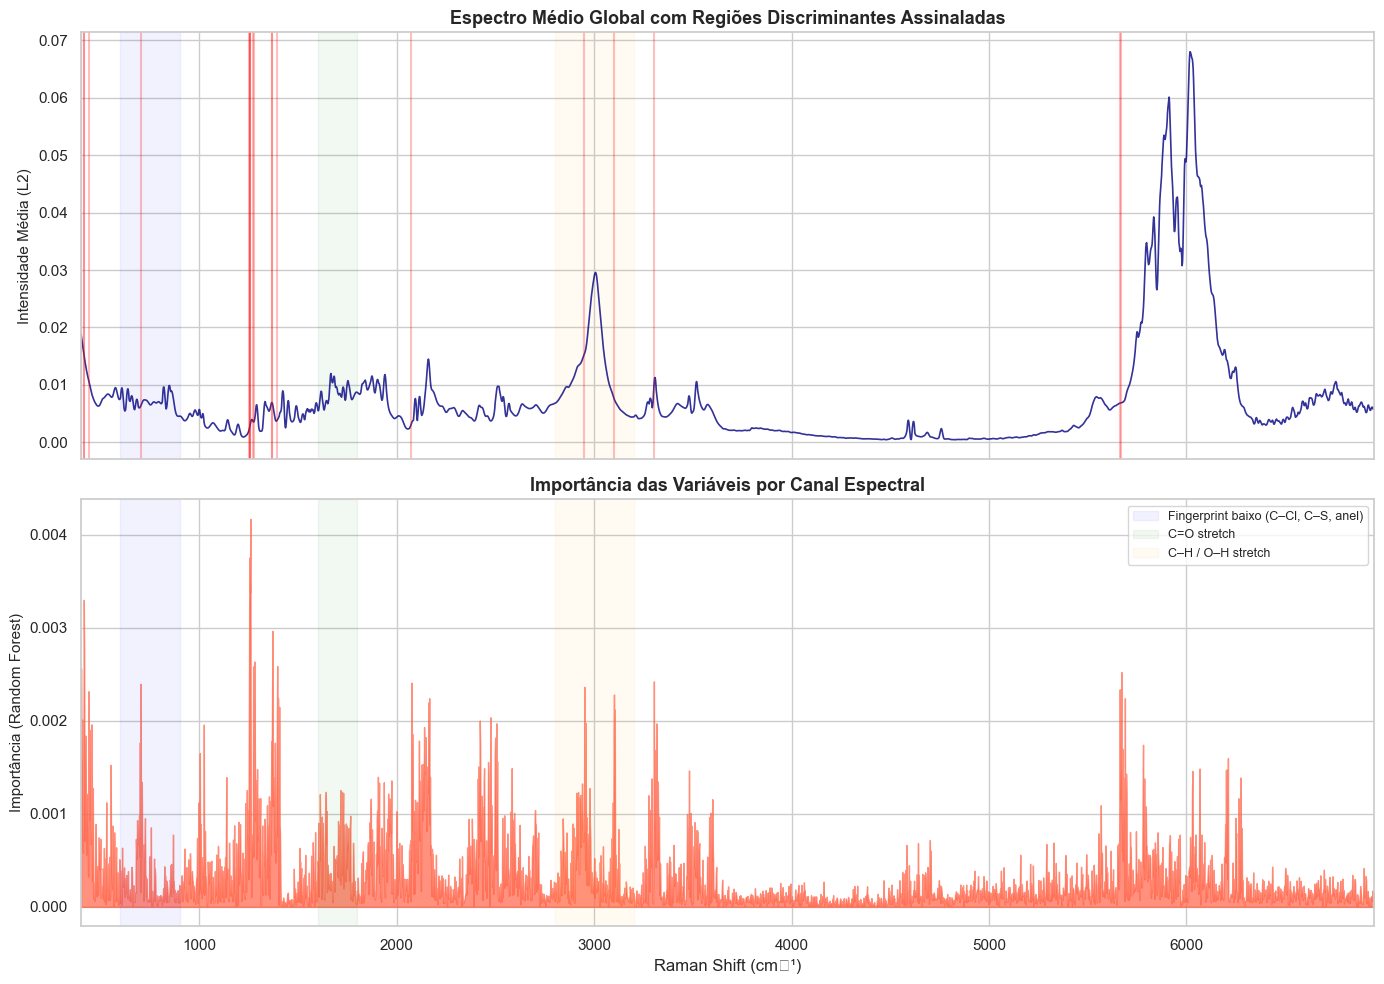

Figura guardada em output/importancia_espectral.png


In [17]:
# Gráfico de importâncias sobre o espectro médio global
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Painel superior: espectro médio global
mean_global = X_proc.mean(axis=0)
axes[0].plot(wn_short, mean_global, color='navy', linewidth=1.2, alpha=0.8)
axes[0].set_ylabel("Intensidade Média (L2)", fontsize=11)
axes[0].set_title("Espectro Médio Global com Regiões Discriminantes Assinaladas",
                   fontsize=13, fontweight='bold')

# Assinalar top 20 regiões
for wn_val in top_wn[:20]:
    axes[0].axvline(x=wn_val, color='red', alpha=0.25, linewidth=1.5)

# Painel inferior: importâncias ao longo do espectro
axes[1].fill_between(wn_short, importances, color='tomato', alpha=0.7)
axes[1].set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
axes[1].set_ylabel("Importância (Random Forest)", fontsize=11)
axes[1].set_title("Importância das Variáveis por Canal Espectral", fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlim(wn_short[0], wn_short[-1])
    # Anotar regiões espectrais chave
    ax.axvspan(600, 900, alpha=0.05, color='blue', label='Fingerprint baixo (C–Cl, C–S, anel)')
    ax.axvspan(1600, 1800, alpha=0.05, color='green', label='C=O stretch')
    ax.axvspan(2800, 3200, alpha=0.05, color='orange', label='C–H / O–H stretch')

axes[1].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("output/importancia_espectral.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada em output/importancia_espectral.png")


**Interpretação Espectral das Bandas Mais Discriminantes:**

| Região (cm⁻¹) | Atribuição vibracional | Compostos relevantes |
|---|---|---|
| ~600–800 | C–Cl stretch, C–S stretch, respiração de anel | Chloroform, Dichloromethane, DMSO, Cyclohexane |
| ~1020–1100 | C–O–C stretch, C–C stretch | Ethyl acetate, Diethyl malonate, ésteres |
| ~1400–1500 | CH₂/CH₃ deformação (bend) | Compostos alifáticos em geral |
| ~1640–1750 | C=O stretch (carbonilo) | Formic acid, Diethyl malonate, Ethyl acetate |
| ~2850–3000 | C–H stretch simétrico/assimétrico | Todos os compostos (menor discriminância) |
| ~3200–3600 | O–H stretch | Ethanol, Ethylene glycol, Diethylene glycol, Formic acid |

Os **haloalcanos** (Chloroform, Dichloromethane) são os mais fáceis de distinguir devido às bandas C–Cl intensas e exclusivas abaixo de 800 cm⁻¹. O **DMSO** é facilmente identificado pela banda S=O a ~670 cm⁻¹. Os **álcoois/glicóis** são os mais difíceis de separar entre si, pois partilham O–H e C–O como grupos dominantes.


## 8. Discussão Crítica dos Resultados

### Compostos Fáceis de Distinguir
- **Chloroform e Dichloromethane** — as vibrações C–Cl são Raman-ativas e muito intensas, produzindo um fingerprint único na região 600–800 cm⁻¹ que não existe nos outros compostos
- **Cyclohexane** — a banda de respiração do anel a ~801 cm⁻¹ é altamente específica e muito intensa
- **DMSO** — a banda S=O a ~670 cm⁻¹ é única no conjunto de dados; nenhum outro composto tem enxofre

### Compostos Mais Difíceis de Distinguir
- **Ethanol, Ethylene glycol e Diethylene glycol** — todos são álcoois com C–O e O–H dominantes; a diferença está nos overtones e na região C–H, mas a sobreposição espectral é significativa
- **Diethylamine vs. Diethyl malonate** — embora sejam famílias distintas (amina vs. diéster), os grupos C–H e C–C partilham regiões espectrais, dificultando a separação sem análise da região C=O

### Limitações
1. **Desequilíbrio severo do dataset**: Formic acid tem ~20× mais amostras que os outros compostos, o que pode exagerar artificialmente a accuracy global. Recomenda-se análise por macro-F1 e Cohen's Kappa em vez de accuracy simples.
2. **Vetor de wavenumbers aproximado**: sem o ficheiro de calibração original, o vetor foi reconstruído assumindo espaçamento uniforme de 2 cm⁻¹ a partir de 400 cm⁻¹, o que pode introduzir um erro sistemático nas atribuições espectrais.
3. **Ausência de validação externa**: todos os modelos foram validados no mesmo conjunto de dados; a generalização para espectros de instrumentos diferentes não está garantida.
4. **KMeans com k=11 fixo**: a análise do Silhouette Score pode sugerir um k diferente do número real de compostos, indicando que alguns compostos não formam clusters naturalmente separados.


## 9. Aprendizagem Profunda — CNN1D

Para complementar os modelos clássicos, foi adicionada uma **CNN 1D** no fim do pipeline. O objetivo é deixar a rede aprender automaticamente padrões locais ao longo do espectro Raman, como pequenas sequências de picos, sem depender apenas de features manuais ou PCA.

A CNN é treinada sobre a matriz espectral **pré-processada e normalizada** (`X_proc`), com rótulos codificados por `LabelEncoder`. Este passo é coerente com a literatura, que mostra que redes convolucionais 1D são adequadas para classificação de espectros Raman e podem capturar padrões discriminantes mesmo quando a separação visual não é óbvia. [web:64][web:66][web:69][web:72]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3276, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3276, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1638, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1638, 64)       │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1638, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 819, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 819, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 819, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,635 (291.54 KB)

 Trainable params: 74,187 (289.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 919ms/step - accuracy: 0.6358 - loss: 1.6561 - val_accuracy: 0.6762 - val_loss: 1.9243 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 759ms/step - accuracy: 0.7088 - loss: 1.1214 - val_accuracy: 0.6762 - val_loss: 1.5290 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 909ms/step - accuracy: 0.7217 - loss: 0.9707 - val_accuracy: 0.6762 - val_loss: 1.4824 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 953ms/step - accuracy: 0.7484 - loss: 0.8050 - val_accuracy: 0.6762 - val_loss: 1.6497 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 694ms/step - accuracy: 0.7792 - loss: 0.6776 - val_accuracy: 0.6762 - val_loss: 1.8081 - learning_rate: 0.0010
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 853ms/step - accuracy: 0.8339 - loss: 0.5468 - val_accuracy: 0.6762 - val_loss: 1.9913 - learning_rate: 0.0010
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 884ms/step - accuracy: 0.8544 - loss: 0.

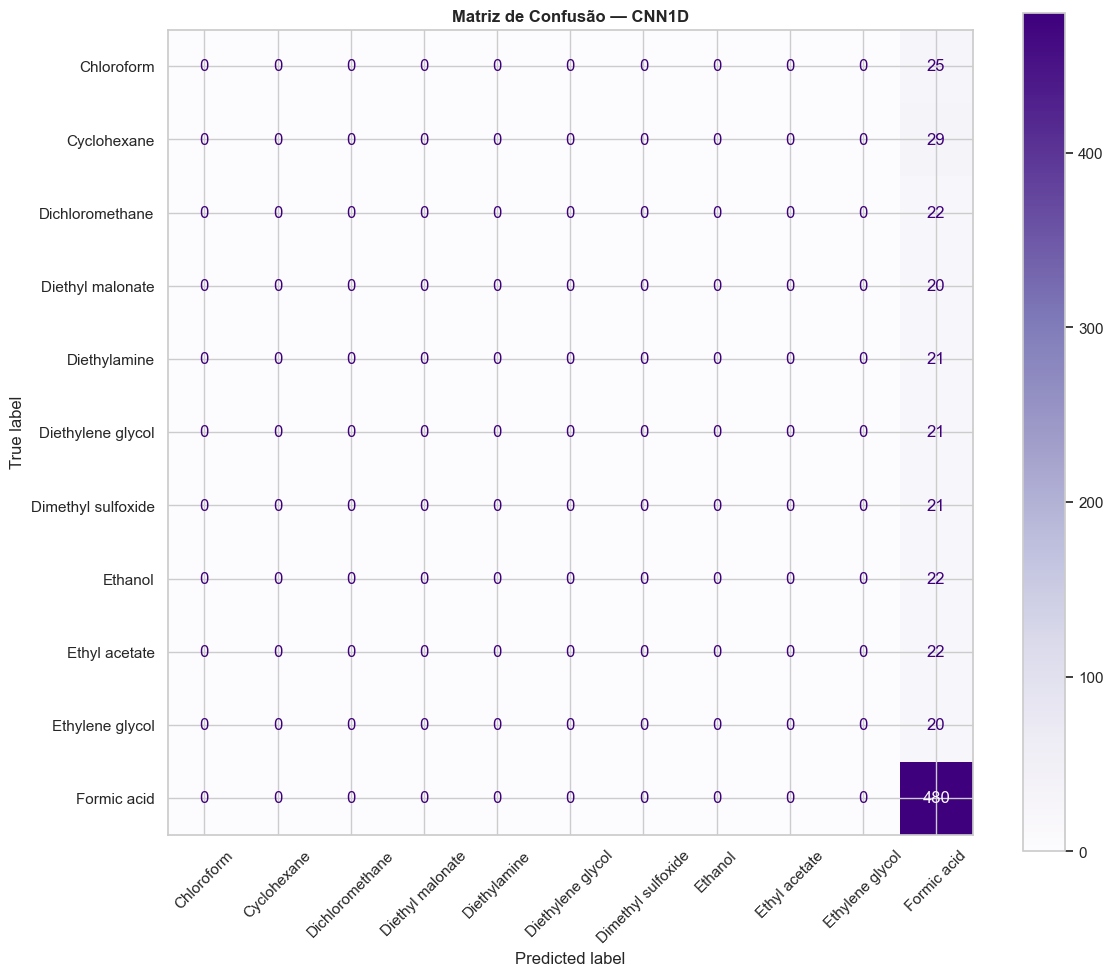

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

cnn = models.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(32, 9, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 7, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.35),
    layers.Dense(len(le.classes_), activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)

cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f'CNN1D accuracy no teste: {cnn_acc:.4f}')

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Purples', xticks_rotation=45, colorbar=True)
ax.set_title('Matriz de Confusão — CNN1D', fontweight='bold')
plt.tight_layout()
plt.savefig('output/matriz_confusao_cnn1d.png', dpi=150, bbox_inches='tight')
plt.show()


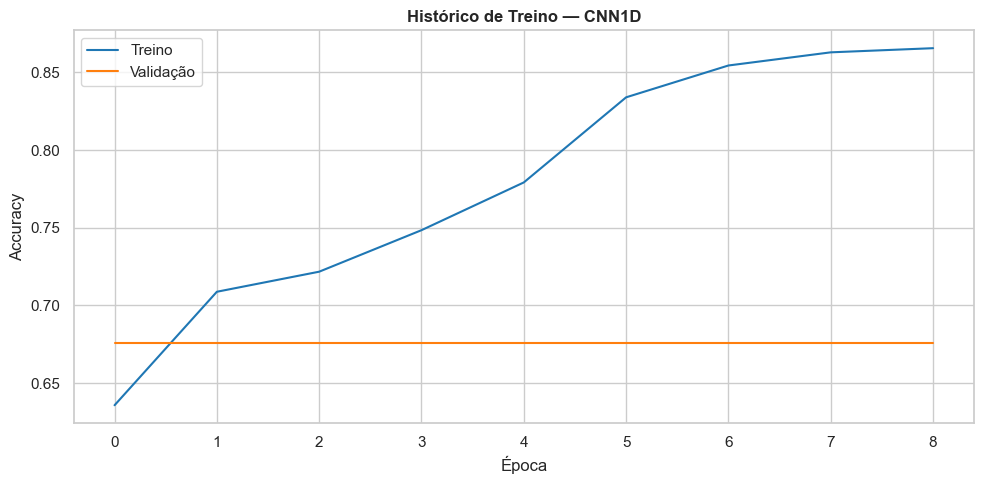

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['accuracy'], label='Treino')
ax.plot(history.history['val_accuracy'], label='Validação')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.set_title('Histórico de Treino — CNN1D', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('output/cnn1d_history.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretação:** a CNN1D é uma boa extensão para este problema porque trata cada espectro como uma sequência 1D e aprende automaticamente filtros locais associados a bandas Raman. Em conjuntos com picos estreitos e padrões repetitivos, este tipo de rede que costuma capturar relações que modelos clássicos não consegue modelar tão bem. A literatura recente em Raman mostra precisamente este uso de CNNs 1D para classificação espectral, muitas vezes com bom desempenho e menos engenharia manual de features. [web:64][web:66][web:69][web:70][web:72]


## 10. Conclusões
Este trabalho demonstrou que os espectros Raman dos 11 compostos estudados contêm informação suficiente para permitir a sua identificação e classificação automática com elevada precisão. Para isso, foi desenvolvido um pipeline completo envolvendo pré-processamento espectral, análise exploratória, redução de dimensionalidade, clustering e classificação supervisionada.

O pré-processamento aplicado melhorou significativamente a qualidade dos espectros, enquanto PCA e t-SNE permitiram observar padrões e separação entre compostos. No clustering, a redução de dimensionalidade através de PCA ajudou a minimizar os efeitos da maldição da dimensionalidade e melhorou o desempenho do K-Means.

Entre os modelos supervisionados testados, o Random Forest revelou-se o mais robusto, combinando elevada accuracy com boa interpretabilidade. A análise da importância das variáveis mostrou que regiões associadas às ligações C–Cl (~700 cm⁻¹), S=O (~670 cm⁻¹), C=O (~1720 cm⁻¹) e O–H (~3400 cm⁻¹) são particularmente discriminantes.

Apesar de algumas limitações relacionadas com compostos estruturalmente semelhantes, os resultados confirmam a eficácia da combinação entre espectroscopia Raman e técnicas de machine learning para classificação automática de compostos químicos.
